In [2]:
import numpy as np 
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import os
import kagglehub
import seaborn as sns

train_csv_path = '/kaggle/input/competitions/aptos2019-blindness-detection/train.csv'
train_images_dir = '/kaggle/input/competitions/aptos2019-blindness-detection/train_images'
train_file_path = '/kaggle/working/train.csv'

test_csv_path = '/kaggle/input/competitions/aptos2019-blindness-detection/test.csv'
test_images_dir = '/kaggle/input/competitions/aptos2019-blindness-detection/test_images'
test_file_path = '/kaggle/working/test.csv'

DATASET_PATH = "/kaggle/input/datasets/omarashour206/aptos2019-preprocessed-dataset/"  

df_train = pd.read_csv(train_csv_path)
df_train['image_path'] = df_train['id_code'].apply(lambda x: os.path.join(train_images_dir, f"{x}.png"))
df_train.to_csv(train_file_path, index=False)

df_test = pd.read_csv(test_csv_path)
df_test['image_path'] = df_test['id_code'].apply(lambda x: os.path.join(test_images_dir, f"{x}.png"))
df_test.to_csv(test_file_path, index=False)



In [3]:
X_train = np.load(DATASET_PATH + "X_train.npy")
y_train = np.load(DATASET_PATH + "y_train.npy")

X_val = np.load(DATASET_PATH + "X_val.npy")
y_val = np.load(DATASET_PATH + "y_val.npy")

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_val shape:   {y_val.shape}")

X_train shape: (4489, 224, 224, 3)
y_train shape: (4489,)
X_val shape:   (733, 224, 224, 3)
y_val shape:   (733,)


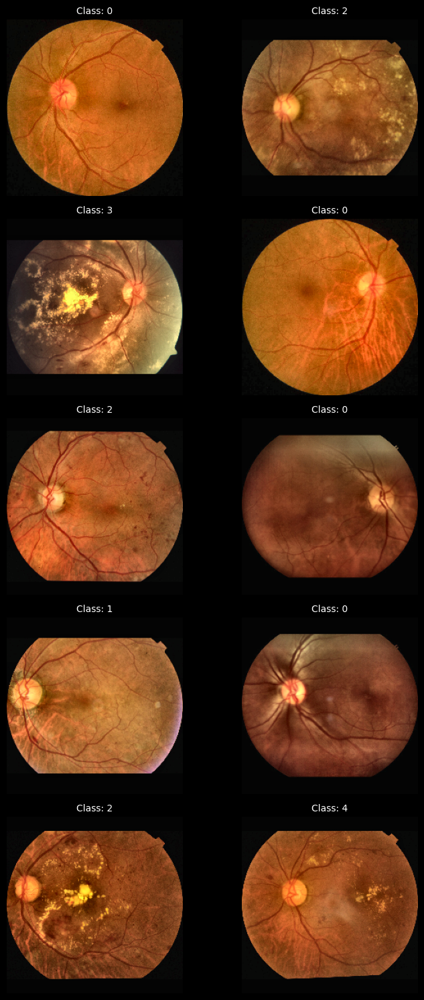

In [11]:
img, axes = plt.subplots(5, 2, figsize=(8, 15), facecolor="black")

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train[i])
    ax.set_title(f"Class: {y_train[i]}", color="white", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

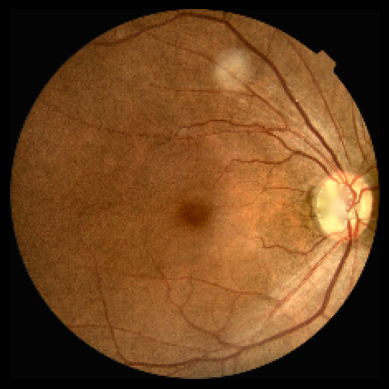

0


In [17]:
image_index = 300
img = X_train[image_index]
label = y_train[image_index]
if img.dtype != np.uint8 and img.max() <= 1.0:
    if img.min() < 0: # Scaled between -1 and 1
        img = (img + 1) / 2.0
plt.figure(facecolor="black")
plt.imshow(img)
plt.axis("off")

plt.show()
print(label)

In [3]:
df_train.head()

,id_code,diagnosis,image_path
0,000c1434d8d7,2,/kaggle/input/competitions/aptos2019-blindness...
1,001639a390f0,4,/kaggle/input/competitions/aptos2019-blindness...
2,0024cdab0c1e,1,/kaggle/input/competitions/aptos2019-blindness...
3,002c21358ce6,0,/kaggle/input/competitions/aptos2019-blindness...
4,005b95c28852,0,/kaggle/input/competitions/aptos2019-blindness...


In [4]:
df_test.head()

,id_code,image_path
0,0005cfc8afb6,/kaggle/input/competitions/aptos2019-blindness...
1,003f0afdcd15,/kaggle/input/competitions/aptos2019-blindness...
2,006efc72b638,/kaggle/input/competitions/aptos2019-blindness...
3,00836aaacf06,/kaggle/input/competitions/aptos2019-blindness...
4,009245722fa4,/kaggle/input/competitions/aptos2019-blindness...


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_code     3662 non-null   object
 1   diagnosis   3662 non-null   int64 
 2   image_path  3662 non-null   object
dtypes: int64(1), object(2)
memory usage: 86.0+ KB


In [6]:
df_train["diagnosis"].value_counts()

diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64

In [7]:
df_train.isnull().sum()

id_code       0
diagnosis     0
image_path    0
dtype: int64

In [10]:
def preprocess_image(img_path, target_size=224):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    _, thresh_outer = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh_outer, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        img = img[y:y+h, x:x+w]

    gray2 = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    mask_retina = cv2.inRange(gray2, 15, 230)
    contours2, _ = cv2.findContours(mask_retina, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours2:
        largest_contour2 = max(contours2, key=cv2.contourArea)
        x2, y2, w2, h2 = cv2.boundingRect(largest_contour2)
        img = img[y2:y2+h2, x2:x2+w2]

    h, w = img.shape[:2]
    size = max(h, w)
    pad_top = (size - h) // 2
    pad_bottom = size - h - pad_top
    pad_left = (size - w) // 2
    pad_right = size - w - pad_left
    img = cv2.copyMakeBorder(img, pad_top, pad_bottom, pad_left, pad_right,
                               cv2.BORDER_CONSTANT, value=[0, 0, 0])

    img = cv2.resize(img, (target_size, target_size))

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    img = img.astype(np.float32) / 255.0
    return img

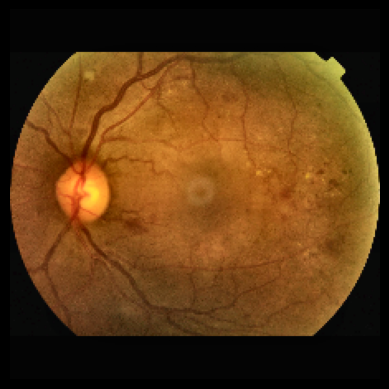

2


In [15]:
test_path = df_train.loc[3000,'image_path']
processed = preprocess_image(test_path)

white_threshold = 2.5
white_mask = (processed.sum(axis=2) > white_threshold)

highlighted_white = processed.copy()
highlighted_white[white_mask] = [1, 0, 0]

fig = plt.figure( facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.imshow(highlighted_white)
plt.axis('off')
plt.show()
plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['savefig.facecolor'] = 'black'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'
white_ratios = []
i =0
for img_path in df_train['image_path'] :
    i +=1
    if i ==100:
        break
    processed = preprocess_image(img_path)
    wr = (processed.sum(axis=2) > 2.9).mean()
    white_ratios.append(wr)
print(df_train.loc[3000,'diagnosis'])

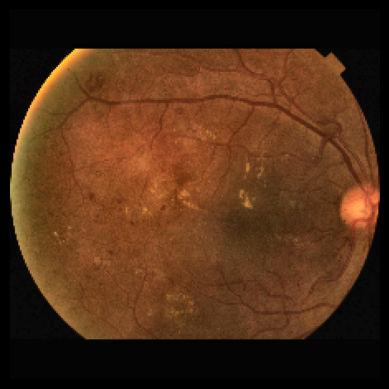

(224, 224, 3)


In [10]:
img = preprocess_image("/kaggle/input/competitions/aptos2019-blindness-detection/train_images/000c1434d8d7.png")
plt.figure(facecolor="black")
plt.imshow(img)
plt.axis("off")
plt.savefig("output.png", bbox_inches="tight", pad_inches=0, facecolor="black")
plt.show()
print(img.shape)

In [11]:
def view_images(group):
    diag = group["diagnosis"].iloc[0]
    print(f"Diagnosis Class {diag}")

    paths = group["image_path"].head(10)

    fig, axes = plt.subplots(2, 5, figsize=(20, 8), facecolor="black")

    for ax, path in zip(axes.ravel(), paths):
        img = preprocess_image(path)
        ax.imshow(img)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


Diagnosis Class 0


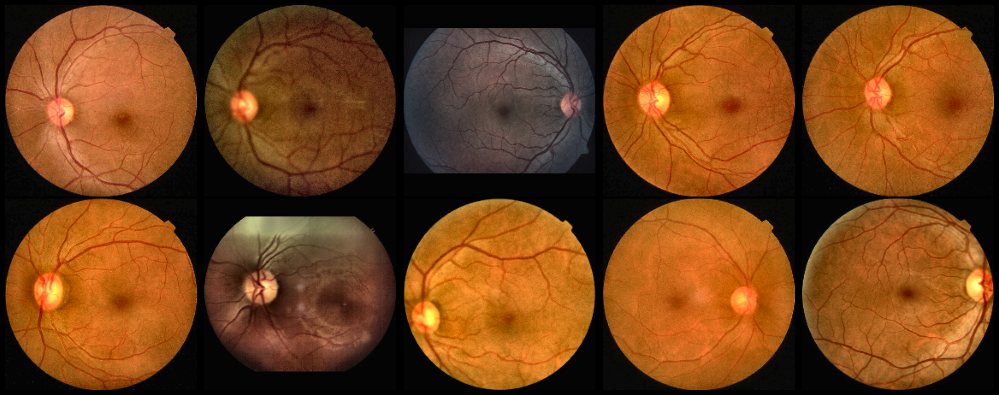

Diagnosis Class 1


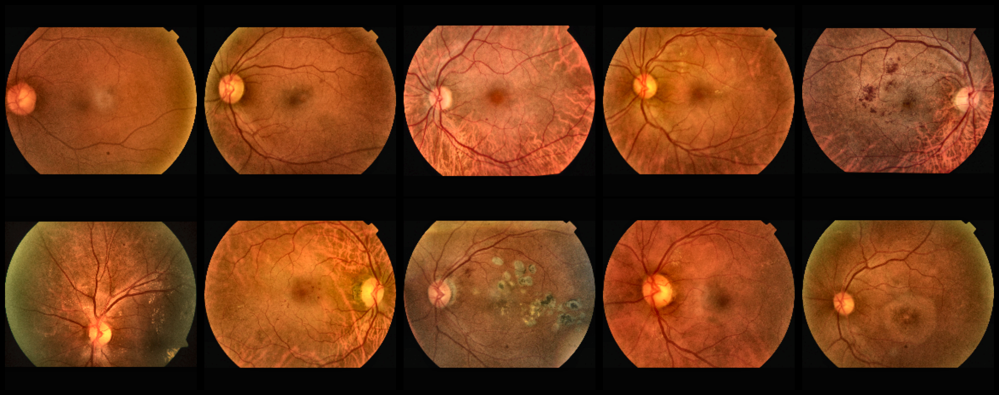

Diagnosis Class 2


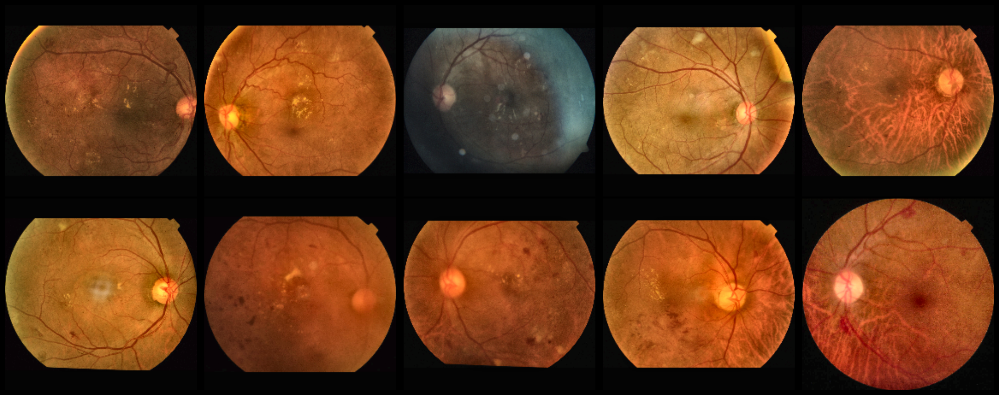

Diagnosis Class 3


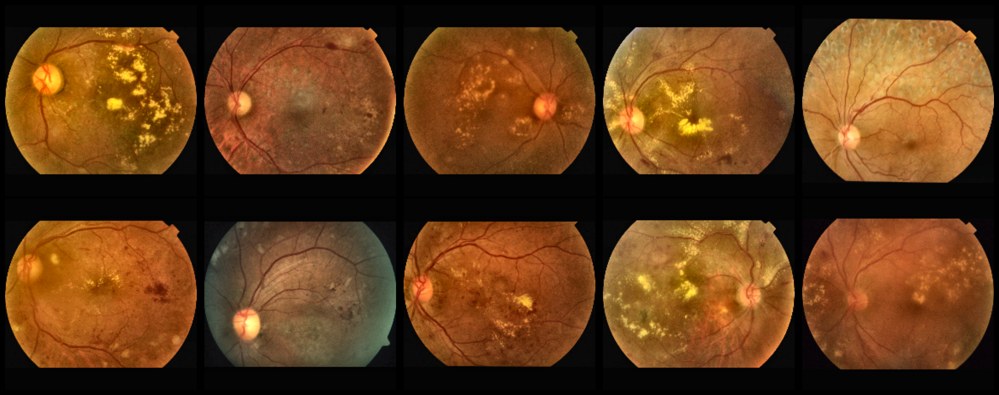

Diagnosis Class 4


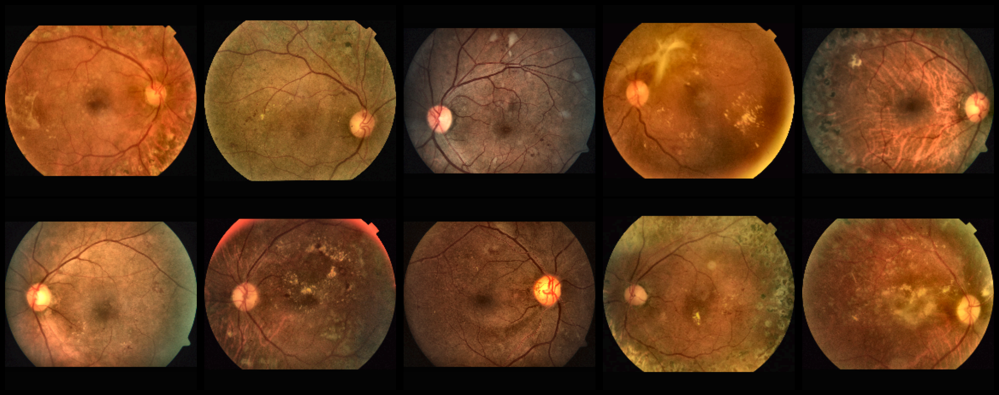

/tmp/ipykernel_58/320998297.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train.groupby("diagnosis", group_keys=False).apply(view_images)


""


In [12]:
df_train.groupby("diagnosis", group_keys=False).apply(view_images)

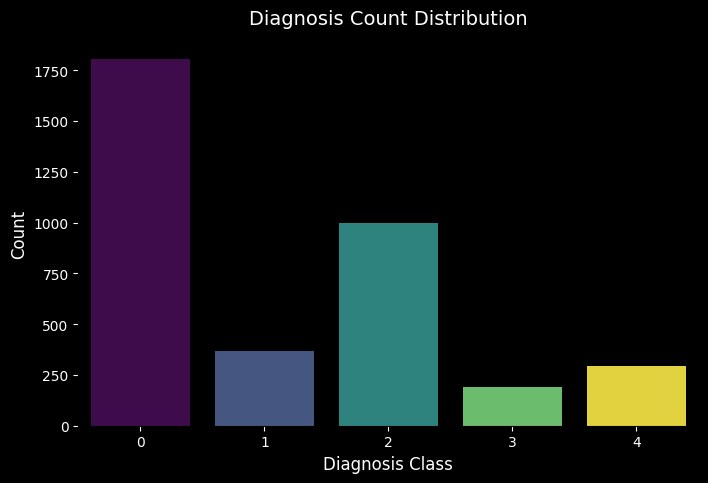

In [15]:
plt.figure(figsize=(8, 5), facecolor="black")
ax = plt.gca()
ax.set_facecolor("black")
sns.countplot(x=df_train["diagnosis"],hue=df_train["diagnosis"],palette="viridis",legend=False,ax=ax,)

plt.title("Diagnosis Count Distribution", color="white", fontsize=14, pad=12)
plt.xlabel("Diagnosis Class", color="white", fontsize=12)
plt.ylabel("Count", color="white", fontsize=12)
ax.tick_params(colors="white")

plt.show()